In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("sentiment_dataset.csv")

In [8]:
df = df.drop(['Unnamed: 0.1','Unnamed: 0'], axis=1)

In [10]:
df.duplicated().sum()

np.int64(21)

In [11]:
df = df.drop_duplicates()

In [12]:
df.nunique()

Text         707
Sentiment    191
Timestamp    683
User         670
Platform       3
Hashtags     692
Retweets      26
Likes         38
Country       33
Year          14
Month         12
Day           31
Hour          22
dtype: int64

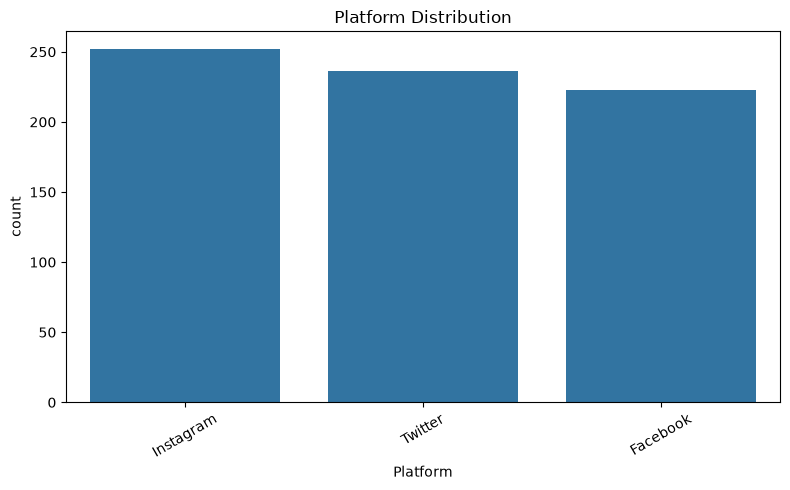

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Platform', order=df['Platform'].value_counts().index)
plt.title('Platform Distribution')
plt.xticks(rotation=30)
plt.tight_layout()

In [14]:
# New stuff for me atleast

In [15]:
df_new = df[['Text', 'Sentiment']]

In [18]:
import re
df_new = df_new[['Text', 'Sentiment']].dropna().copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S','',text)
    text = re.sub(r'@\w+','',text)
    text = re.sub(r'#\w+','',text)
    text = re.sub(r'<.*?>','',text)
    text = re.sub(r'\d+','',text)
    text = re.sub(r'[^\w\s]','',text)
    text = re.sub(r'_','',text)
    text = re.sub(r'\s+','',text).strip()
    return text

df_new['Text'] = df_new['Text'].apply(clean_text)

df_new = df_new[df_new['Text'].str.len() > 0].reset_index(drop=True)

display(df_new.head(10))
print(df_new.shape)

,Text,Sentiment
0,enjoyingabeautifuldayatthepark,Positive
1,trafficwasterriblethismorning,Negative
2,justfinishedanamazingworkout,Positive
3,excitedabouttheupcomingweekendgetaway,Positive
4,tryingoutanewrecipefordinnertonight,Neutral
5,feelinggratefulforthelittlethingsinlife,Positive
6,rainydayscallforcozyblanketsandhotcocoa,Positive
7,thenewmoviereleaseisamustwatch,Positive
8,politicaldiscussionsheatinguponthetimeline,Negative
9,missingsummervibesandbeachdays,Neutral


(711, 2)


In [19]:
df_new['Sentiment'] = df_new['Sentiment'].astype(str).str.strip()

positive_labels = {
    'Positive', 'Happiness', 'Happy', 'Joy', 'Love', 'Amusement',
    'Enjoyment', 'Admiration', 'Affection', 'Awe', 'Acceptance',
    'Adoration', 'Anticipation', 'Calmness', 'Excitement', 'Kind',
    'Pride', 'Elation', 'Euphoria', 'Contentment', 'Serenity',
    'Gratitude', 'Hope', 'Empowerment', 'Compassion', 'Tenderness',
    'Enthusiasm', 'Fulfillment', 'Reverence', 'Curiosity',
    'Determination', 'Zest', 'Hopeful', 'Proud', 'Grateful',
    'Empathetic', 'Compassionate', 'Playful', 'Free-spirited',
    'Inspired', 'Confident', 'Thrill', 'Overjoyed', 'Inspiration',
    'Motivation', 'Contemplation', 'JoyfulReunion', 'Satisfaction',
    'Blessed', 'Reflection', 'Appreciation', 'Confidence',
    'Accomplishment', 'Wonderment', 'Optimism', 'Enchantment',
    'Intrigue', 'PlayfulJoy', 'Mindfulness', 'DreamChaser',
    'Elegance', 'Whimsy', 'Harmony', 'Creativity', 'Radiance',
    'Wonder', 'Rejuvenation', 'Coziness', 'Adventure', 'Melodic',
    'FestiveJoy', 'InnerJourney', 'Freedom', 'Dazzle', 'Adrenaline',
    'ArtisticBurst', 'CulinaryOdyssey', 'Resilience', 'Immersion',
    'Spark', 'Marvel', 'Positivity', 'Kindness', 'Friendship',
    'Success', 'Exploration', 'Amazement', 'Romance', 'Captivation',
    'Tranquility', 'Grandeur', 'Emotion', 'Energy', 'Celebration',
    'Charm', 'Ecstasy', 'Colorful', 'Hypnotic', 'Connection',
    'Iconic', 'Journey', 'Engagement', 'Touched', 'Satisfaction',
    'Triumph', 'Heartwarming', 'Sympathy', 'Solace', 'Breakthrough',
    'Joy in Baking', 'Envisioning History', 'Imagination', 'Vibrancy',
    'Mesmerizing', 'Culinary Adventure', 'Winter Magic',
    'Thrilling Journey', "Nature's Beauty", 'Celestial Wonder',
    'Creative Inspiration', 'Runway Creativity', "Ocean's Freedom",
    'Whispers of the Past', 'Relief'
}

negative_labels = {
    'Negative', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Disappointed',
    'Bitter', 'Shame', 'Despair', 'Grief', 'Loneliness', 'Jealousy',
    'Resentment', 'Frustration', 'Boredom', 'Anxiety', 'Intimidation',
    'Helplessness', 'Envy', 'Regret', 'Numbness', 'Melancholy',
    'Nostalgia', 'Ambivalence', 'Bitterness', 'Yearning', 'Fearful',
    'Apprehensive', 'Overwhelmed', 'Jealous', 'Devastated',
    'Frustrated', 'Envious', 'Dismissive', 'Heartbreak', 'Betrayal',
    'Suffering', 'EmotionalStorm', 'Isolation', 'Disappointment',
    'LostLove', 'Exhaustion', 'Sorrow', 'Darkness', 'Desperation',
    'Ruins', 'Desolation', 'Loss', 'Heartache', 'Solitude',
    'Hate', 'Bad', 'Embarrassed', 'Pressure', 'Miscalculation',
    'Obstacle', 'Challenge'
}

neutral_labels = {
    'Neutral', 'Confusion', 'Indifference', 'Contemplation',
    'Reflection', 'Pensive', 'Acceptance'
}

def map_sentiment(label):
    label = label.strip()
    
    if label in positive_labels:
        return 'Positive'
    elif label in negative_labels:
        return 'Negative'
    elif label in neutral_labels:
        return 'Neutral'
    else:
        return 'Neutral'

df_new['Sentiment'] = df_new['Sentiment'].apply(map_sentiment)

print(df_new['Sentiment'].value_counts())
print(df_new['Sentiment'].value_counts(normalize=True).mul(100).round(2))

display(df_new.head(20))


Sentiment
Positive    458
Negative    196
Neutral      57
Name: count, dtype: int64
Sentiment
Positive    64.42
Negative    27.57
Neutral      8.02
Name: proportion, dtype: float64


,Text,Sentiment
0,enjoyingabeautifuldayatthepark,Positive
1,trafficwasterriblethismorning,Negative
2,justfinishedanamazingworkout,Positive
3,excitedabouttheupcomingweekendgetaway,Positive
4,tryingoutanewrecipefordinnertonight,Neutral
5,feelinggratefulforthelittlethingsinlife,Positive
6,rainydayscallforcozyblanketsandhotcocoa,Positive
7,thenewmoviereleaseisamustwatch,Positive
8,politicaldiscussionsheatinguponthetimeline,Negative
9,missingsummervibesandbeachdays,Neutral


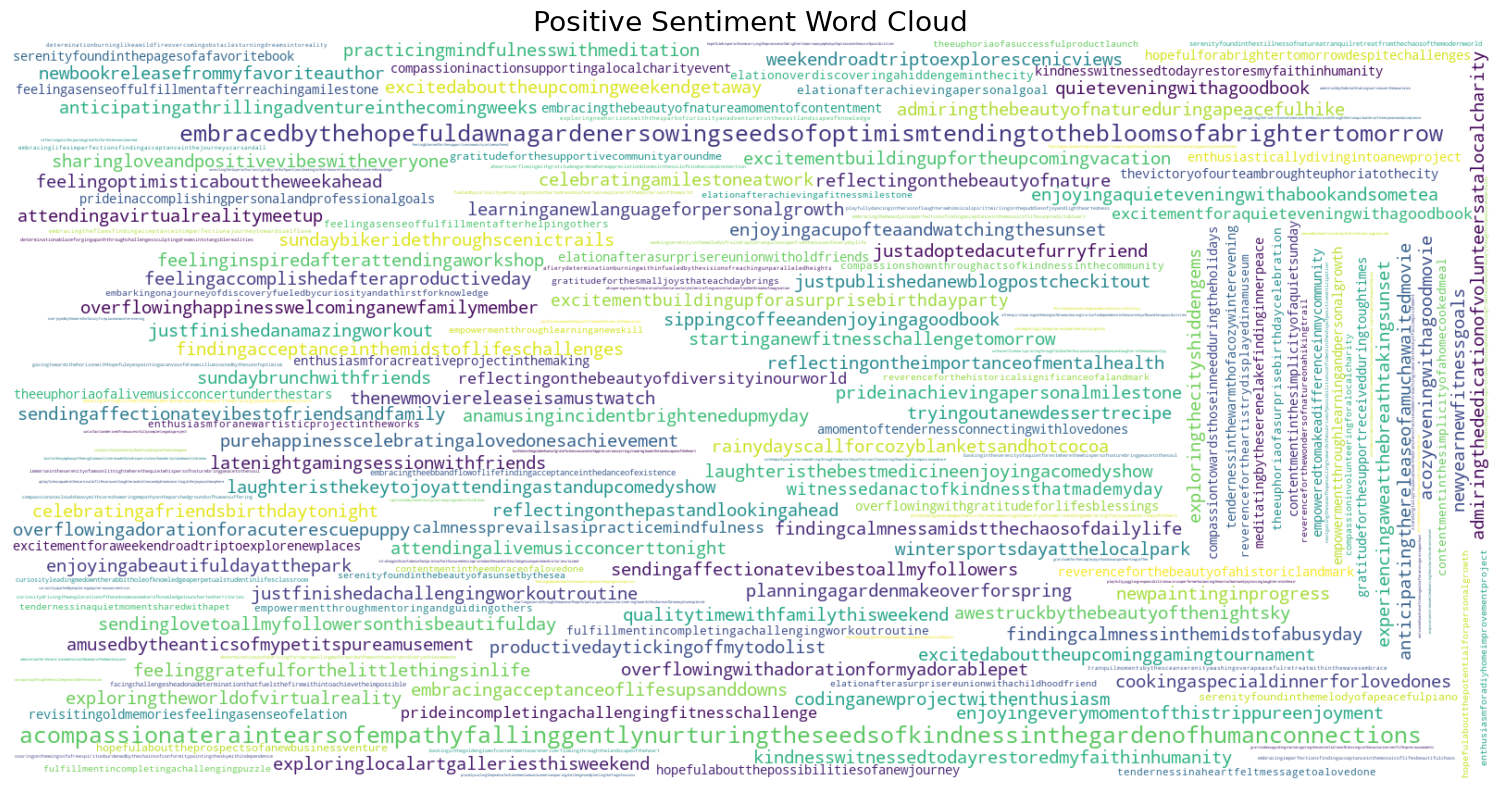

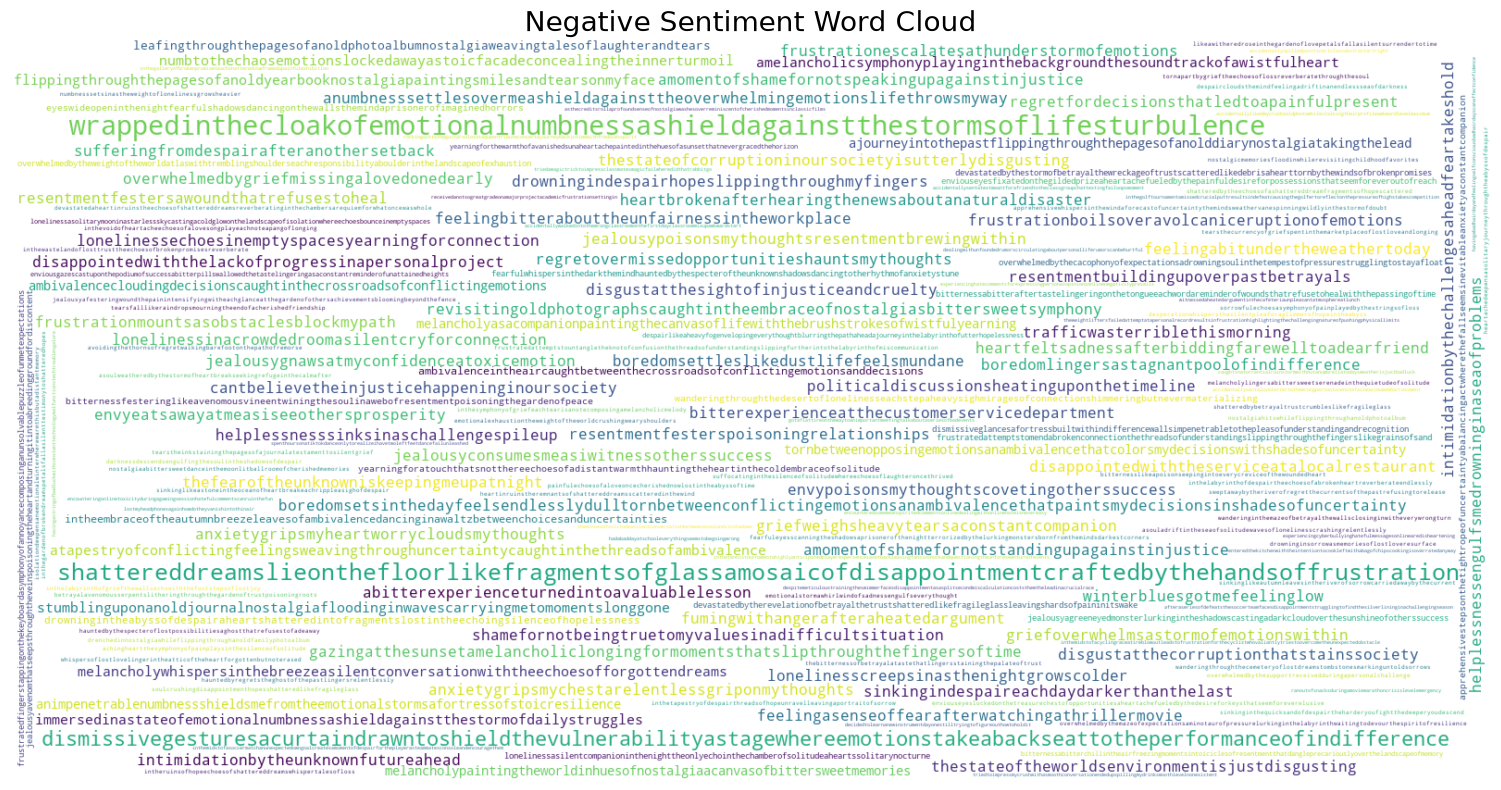

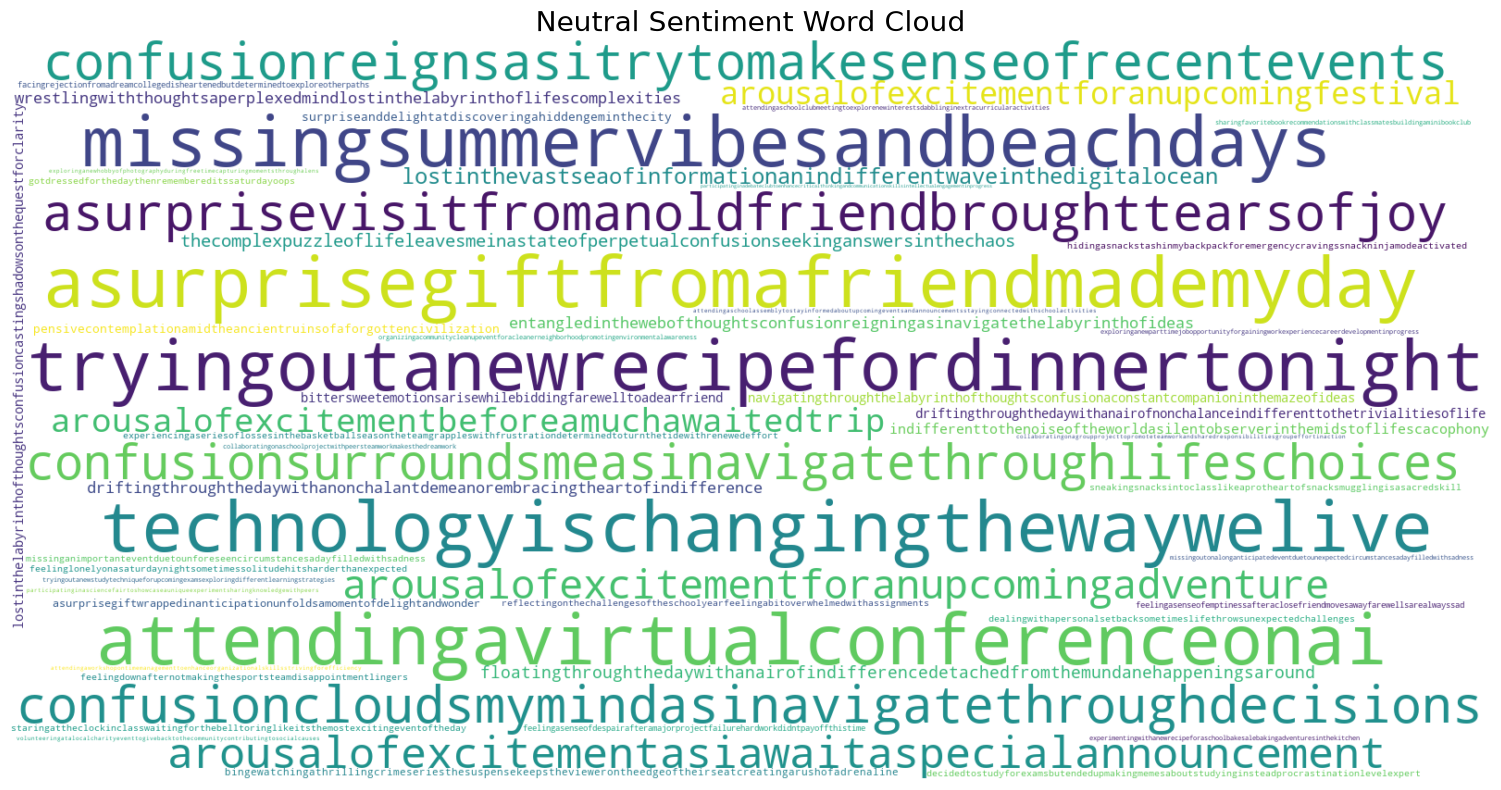

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for sentiment in ['Positive', 'Negative', 'Neutral']:
    text = ' '.join(
        df_new.loc[df_new['Sentiment'] == sentiment, 'Text'].astype(str)
    )

    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='white',
        max_words=200,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{sentiment} Sentiment Word Cloud', fontsize=20)
    plt.tight_layout()
    plt.show()


Classes: ['Negative' 'Neutral' 'Positive']

Class distribution:
Sentiment
Positive    458
Negative    196
Neutral      57
Name: count, dtype: int64

TF-IDF Training Shape: (568, 3)
TF-IDF Testing Shape: (143, 3)

Before SMOTE:
0    157
1     45
2    366
Name: count, dtype: int64

After SMOTE:
0    366
1    366
2    366
Name: count, dtype: int64

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        39
     Neutral       0.08      1.00      0.15        12
    Positive       0.00      0.00      0.00        92

    accuracy                           0.08       143
   macro avg       0.03      0.33      0.05       143
weighted avg       0.01      0.08      0.01       143


Decision Tree
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        39
     Neutral       0.08      1.00      0.15        12
    Positive       0.00      0.00      0.00        92

    accuracy      

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.0839,0.0070,0.0839,0.0130
1,Decision Tree,0.0839,0.0070,0.0839,0.0130
2,Bayes Theorem,0.2727,0.0744,0.2727,0.1169


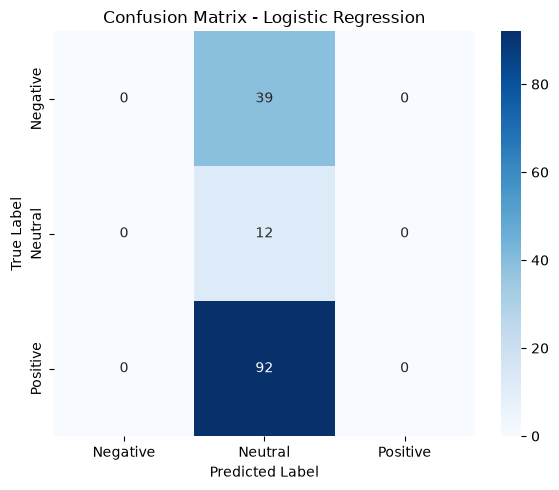

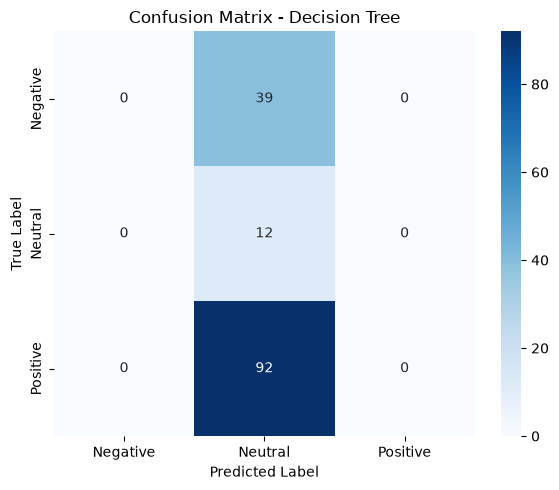

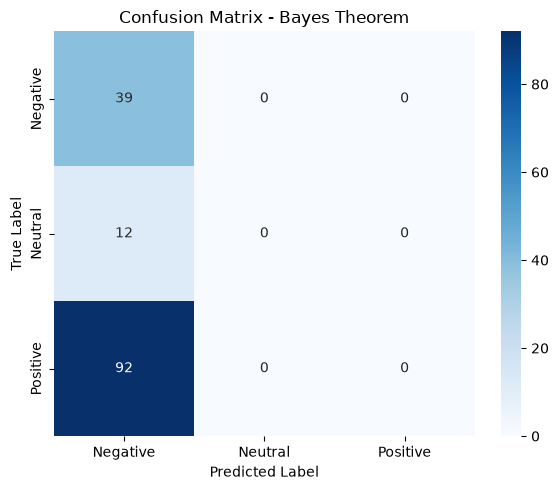

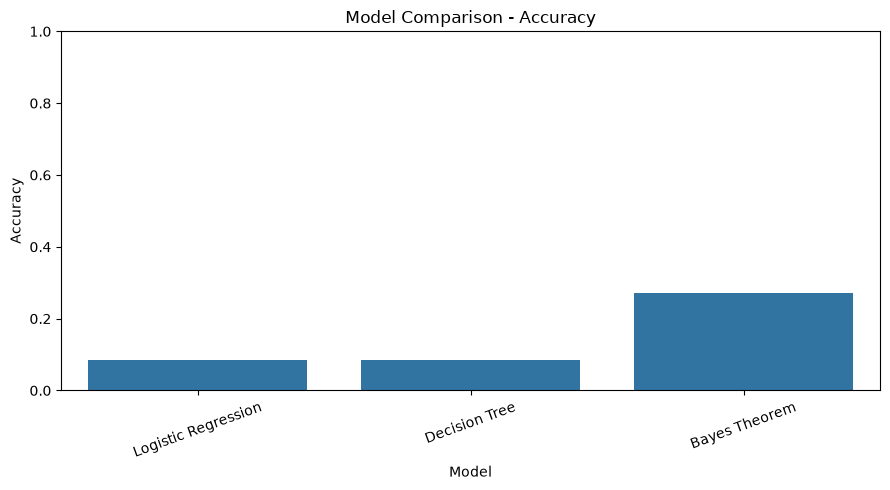

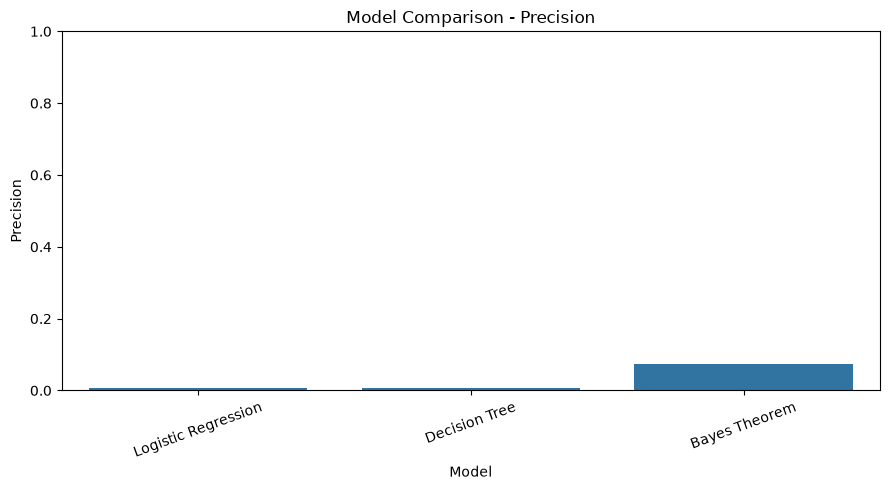

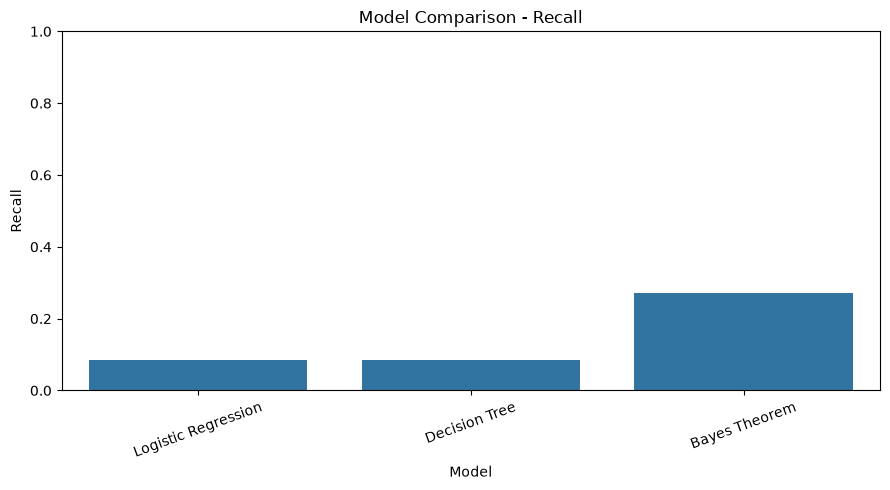

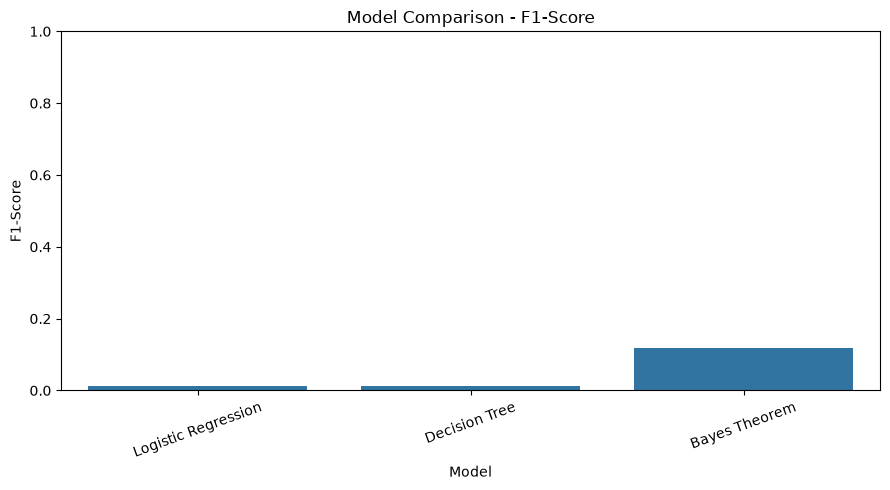

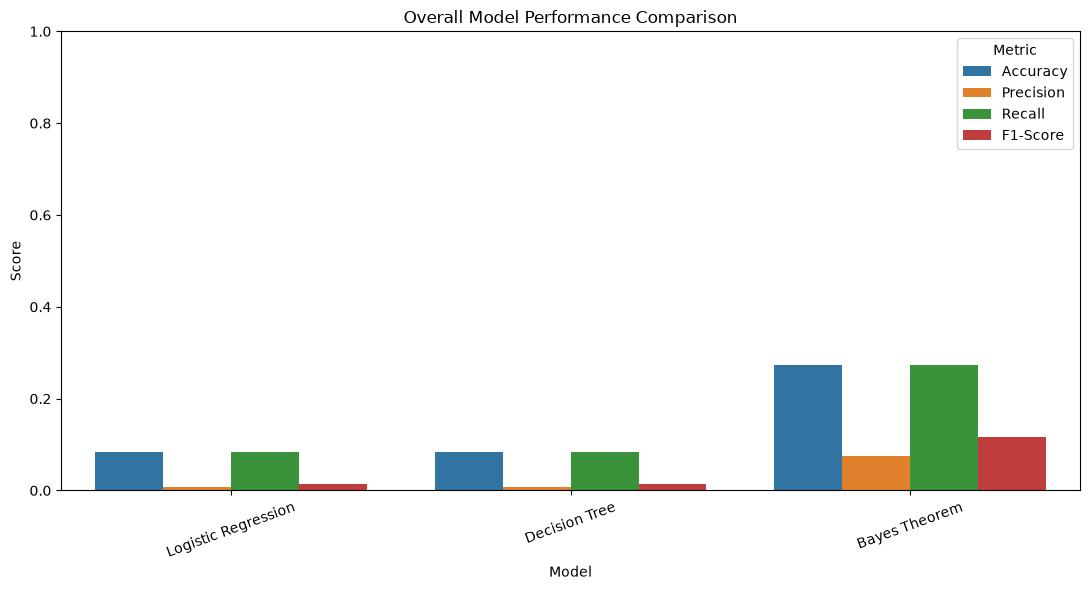


Best Model:
Model        Bayes Theorem
Accuracy          0.272727
Precision          0.07438
Recall            0.272727
F1-Score          0.116883
Name: 2, dtype: object


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

SEED = 42

df_model = df_new[['Text', 'Sentiment']].dropna().copy()

df_model['Text'] = df_model['Text'].astype(str)
df_model['Sentiment'] = df_model['Sentiment'].astype(str).str.strip()

le = LabelEncoder()
y = le.fit_transform(df_model['Sentiment'])
X_text = df_model['Text']

print('Classes:', le.classes_)
print('\nClass distribution:')
print(df_model['Sentiment'].value_counts())

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print('\nTF-IDF Training Shape:', X_train_tfidf.shape)
print('TF-IDF Testing Shape:', X_test_tfidf.shape)

smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

print('\nBefore SMOTE:')
print(pd.Series(y_train).value_counts().sort_index())

print('\nAfter SMOTE:')
print(pd.Series(y_train_smote).value_counts().sort_index())

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=SEED
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=SEED,
        max_depth=20,
        min_samples_split=4
    ),
    
    'Bayes Theorem': MultinomialNB()
}

results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_tfidf)

    predictions[name] = y_pred

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'Recall': recall_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'F1-Score': f1_score(
            y_test, y_pred, average='weighted', zero_division=0
        )
    })

    print('\n' + '=' * 70)
    print(name)
    print('=' * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            zero_division=0
        )
    )

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}'
    })
)

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics:

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=results_df,
        x='Model',
        y=metric
    )

    plt.title(f'Model Comparison - {metric}')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

comparison_long = results_df.melt(
    id_vars='Model',
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Overall Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model = results_df.loc[
    results_df['F1-Score'].idxmax()
]

print('\nBest Model:')
print(best_model)






